<a href="https://colab.research.google.com/github/Kaviyasree-N/ML-PROJECT/blob/main/email_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET LOADED
Dataset shape: (5809, 7)

Columns:
['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Missing values:
sender        0
receiver    210
date          0
subject      16
body          1
label         0
urls          0
dtype: int64

Label distribution:
label
0    4091
1    1718
Name: count, dtype: int64

Duplicate emails removed: 0

Final label distribution:
label
0    4091
1    1718
Name: count, dtype: int64

Emails available for training: 5809

Example cleaned email:
re new sequences window date wed NUMBER aug NUMBER NUMBER NUMBER NUMBER NUMBER from chris garrigues message id i can t reproduce this error for me it is very repeatable like every time without fail this is the debug log of the pick happening NUMBER NUMBER NUMBER pick it exec pick inbox list lbrace lbrace subject ftp rbrace rbrace NUMBER NUMBER sequence mercury NUMBER NUMBER NUMBER exec pick inbox list lbrace lbrace subject ftp rbrace rbrace NUMBER NUMBER sequence mercury NUMBER NUMBER NUMBER ft

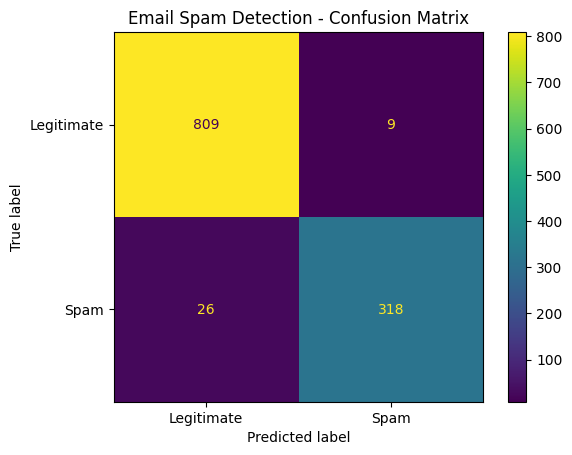


FILES SAVED
email_naive_bayes_model.pkl
email_tfidf_vectorizer.pkl

TEST 1 - SPAM EMAIL
{'prediction': 'Spam', 'confidence': np.float64(70.42)}

TEST 2 - LEGITIMATE EMAIL
{'prediction': 'Legitimate', 'confidence': np.float64(88.71)}

TEST 3 - SUSPICIOUS EMAIL
{'prediction': 'Spam', 'confidence': np.float64(78.84)}

FINAL SUMMARY
Dataset              : SpamAssasin.csv
Total emails         : 5809
Training emails      : 4647
Testing emails       : 1162
Model                : Multinomial Naive Bayes
Text representation  : TF-IDF
Accuracy             : 96.99%
Precision            : 97.25%
Recall               : 92.44%
F1 Score             : 94.78%

Model files are ready for FastAPI integration.


In [ ]:
# ============================================================
# EMAIL SPAM DETECTION - FINAL VERSION
# Dataset: SpamAssasin.csv
# Model: TF-IDF + Multinomial Naive Bayes
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import re
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# 2. LOAD DATASET
# -----------------------------

# If using Google Colab, upload SpamAssasin.csv
# and make sure the file is available in /content/

file_path = "/content/SpamAssasin.csv"

# If the file is not in /content, try the current directory
if not os.path.exists(file_path):
    file_path = "SpamAssasin.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(
        "SpamAssasin.csv was not found. "
        "Please upload the dataset to your notebook environment."
    )

df = pd.read_csv(file_path)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# -----------------------------
# 3. CHECK DATASET
# -----------------------------

print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())

# -----------------------------
# 4. KEEP REQUIRED COLUMNS
# -----------------------------

required_columns = ["subject", "body", "label"]

for column in required_columns:
    if column not in df.columns:
        raise ValueError(f"Required column '{column}' is missing.")

df = df[required_columns].copy()

# -----------------------------
# 5. HANDLE MISSING VALUES
# -----------------------------

df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

# Convert to string
df["subject"] = df["subject"].astype(str)
df["body"] = df["body"].astype(str)

# -----------------------------
# 6. REMOVE DUPLICATE EMAILS
# -----------------------------

before_duplicates = len(df)

df = df.drop_duplicates(
    subset=["subject", "body"]
).reset_index(drop=True)

after_duplicates = len(df)

print("\nDuplicate emails removed:",
      before_duplicates - after_duplicates)

# -----------------------------
# 7. VERIFY LABELS
# -----------------------------

# Based on inspection of SpamAssasin.csv:
# 0 = Legitimate
# 1 = Spam

df["label"] = pd.to_numeric(df["label"], errors="coerce")

df = df.dropna(subset=["label"])

df["label"] = df["label"].astype(int)

# Keep only valid labels
df = df[df["label"].isin([0, 1])].reset_index(drop=True)

print("\nFinal label distribution:")
print(df["label"].value_counts())

# -----------------------------
# 8. TEXT CLEANING FUNCTION
# -----------------------------

def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Replace URLs with a common token
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " URL ",
        text
    )

    # Replace email addresses
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        " EMAIL ",
        text
    )

    # Replace numbers with a common token
    text = re.sub(r"\b\d+\b", " NUMBER ", text)

    # Keep letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# -----------------------------
# 9. COMBINE SUBJECT + BODY
# -----------------------------

df["combined_text"] = (
    df["subject"] + " " + df["body"]
)

# Clean the email text
df["cleaned_text"] = df["combined_text"].apply(clean_text)

# Remove empty emails
df = df[df["cleaned_text"].str.strip() != ""].reset_index(drop=True)

print("\nEmails available for training:", len(df))

# -----------------------------
# 10. DISPLAY EXAMPLE
# -----------------------------

print("\nExample cleaned email:")
print(df["cleaned_text"].iloc[0][:500])

# -----------------------------
# 11. SPLIT DATA
# -----------------------------

X = df["cleaned_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training emails:", len(X_train))
print("Testing emails :", len(X_test))

# -----------------------------
# 12. TF-IDF VECTORIZATION
# -----------------------------

vectorizer = TfidfVectorizer(
    max_features=15000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

# IMPORTANT:
# Fit only on training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF vocabulary size:",
      len(vectorizer.vocabulary_))

print("Training TF-IDF shape:",
      X_train_tfidf.shape)

print("Testing TF-IDF shape:",
      X_test_tfidf.shape)

# -----------------------------
# 13. TRAIN MULTINOMIAL NAIVE BAYES
# -----------------------------

model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)

print("\n" + "=" * 60)
print("MODEL TRAINING COMPLETED")
print("=" * 60)

print("Model: Multinomial Naive Bayes")

# -----------------------------
# 14. PREDICT TEST DATA
# -----------------------------

y_pred = model.predict(X_test_tfidf)

# -----------------------------
# 15. EVALUATION
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

# -----------------------------
# 16. CLASSIFICATION REPORT
# -----------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Spam"],
        zero_division=0
    )
)

# -----------------------------
# 17. CONFUSION MATRIX
# -----------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Spam"]
)

disp.plot()

plt.title("Email Spam Detection - Confusion Matrix")
plt.show()

# -----------------------------
# 18. SAVE MODEL + VECTORIZER
# -----------------------------

joblib.dump(
    model,
    "email_naive_bayes_model.pkl"
)

joblib.dump(
    vectorizer,
    "email_tfidf_vectorizer.pkl"
)

print("\n" + "=" * 60)
print("FILES SAVED")
print("=" * 60)

print("email_naive_bayes_model.pkl")
print("email_tfidf_vectorizer.pkl")

# -----------------------------
# 19. EMAIL PREDICTION FUNCTION
# -----------------------------

def predict_email(subject, body, urls=""):

    # Combine subject and body
    email_text = str(subject) + " " + str(body)

    # Clean text
    cleaned_email = clean_text(email_text)

    # Convert text to TF-IDF
    email_vector = vectorizer.transform(
        [cleaned_email]
    )

    # Prediction
    prediction = model.predict(
        email_vector
    )[0]

    # Probability
    probabilities = model.predict_proba(
        email_vector
    )[0]

    confidence = max(probabilities) * 100

    # Convert numerical prediction
    if prediction == 1:
        result = "Spam"
    else:
        result = "Legitimate"

    return {
        "prediction": result,
        "confidence": round(confidence, 2)
    }


# -----------------------------
# 20. TEST EMAIL 1 - SPAM
# -----------------------------

print("\n" + "=" * 60)
print("TEST 1 - SPAM EMAIL")
print("=" * 60)

result1 = predict_email(
    subject="Congratulations! You have won a $1,000,000 prize",
    body="""
    You have been selected as the lucky winner.
    Click the link below immediately to claim your prize.
    Send your personal information to receive the money.
    """
)

print(result1)

# -----------------------------
# 21. TEST EMAIL 2 - LEGITIMATE
# -----------------------------

print("\n" + "=" * 60)
print("TEST 2 - LEGITIMATE EMAIL")
print("=" * 60)

result2 = predict_email(
    subject="Meeting scheduled for tomorrow",
    body="""
    Hi team,

    Our project meeting is scheduled for tomorrow
    at 10 AM in the conference room.

    Please bring your project updates.

    Thanks.
    """
)

print(result2)

# -----------------------------
# 22. TEST EMAIL 3
# -----------------------------

print("\n" + "=" * 60)
print("TEST 3 - SUSPICIOUS EMAIL")
print("=" * 60)

result3 = predict_email(
    subject="Your account has been suspended",
    body="""
    Your account will be permanently closed.
    Verify your account immediately by clicking
    the link below and entering your password.
    """
)

print(result3)

# -----------------------------
# 23. FINAL SUMMARY
# -----------------------------

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("Dataset              : SpamAssasin.csv")
print("Total emails         :", len(df))
print("Training emails      :", len(X_train))
print("Testing emails       :", len(X_test))
print("Model                : Multinomial Naive Bayes")
print("Text representation  : TF-IDF")
print(f"Accuracy             : {accuracy * 100:.2f}%")
print(f"Precision            : {precision * 100:.2f}%")
print(f"Recall               : {recall * 100:.2f}%")
print(f"F1 Score             : {f1 * 100:.2f}%")

print("\nModel files are ready for FastAPI integration.")
print("============================================================")